# The basics of Machine Learning

## 1 - Classification versus regression

In supervised learning, two classes of problems can be distinguished according to the kind of an output target data $y^t$ :

*   When $y^t$ is continuous ($y^t \in \mathbb{R}$) it is a regression problem;
*   When $y^t$ is discrete or category (like $y^t \in \{0,1\}$) it is a classification problem.

## 2 - Training a ML model

The data set, which is composed of data samples $(X_j,Y^t_j)_{j \in \{1,\dots,n\}}$, where $X_j=\left(x_{1j},\dots,x_{Ij}\right)$ and $Y^t_j=\left(y^t_{1j},\dots,y^t_{Oj}\right)$ with $I$ and $O$ being the number of input and output variables respectively,, is usually divided into three sets (examples possible splitting ratio are given between brackets; their sum must be always equal to 100%):
1.   training / learning set $(X_{train},Y^t_{train})$ (60%; 70%; 70%)
2.   validation set $(X_{validation},Y^t_{validation})$ (20%; 15%; 0%)
3.   test set $(X_{test},Y^t_{test})$ (20%; 15%; 30%)

The training set contains the data used to find the model's optimal parameters, while the validation set is used to check whether the training is still relevant or whether an overfit appears, meaning that the model is no longer able to generalize and therefore give good predictions for the new data encountered. The test set is used to evaluate the model's performance once training is complete.

Finding a model's optimal parameters means to find a set of parameters $\Theta$ (the set of synaptic weights $W$ in the context of a neural network) such that the model gives good predictions $Y$ for inputs $X$ considering a giving configuration of model's hyperparameters (learning rate, tree depth, and so on). This is done by finding a set $\hat{\Theta}$ that minimizes an Error / Loss function $L$ that drives the training
$$ \min_{\Theta} \left[ \frac{1}{n} \sum_{j=1}^{n} L\left(P_\Theta(X_j),Y^t_j\right) \right]$$
where $P_\Theta(X_j)$ is the model's prediction for a data sample $(X_j,Y^t_j)$ belonging to $(X_{train},Y^t_{train})$.

A common choice for the loss function is the Mean Squared Error $\rightarrow L\left(y,y^t\right) = \frac{1}{2} \left(y - y^t\right)^2$, where $\frac{1}{2}$ can be dropped.

## 3 - Evaluating the performance of a Machine Learning model

Once $\hat{\Theta}$ found, the model is evaluated on the test set $(X_{test},Y^t_{test})$ using a metric $d(P_{\hat{\Theta}}(X_{test}),Y^t_{test}) \in \mathbb{R}$, which can the loss function $L$ or another one not used for training.

## 4 - Optimization of hyperparameters

Once the model trained and evaluated, a further step is to optimize the hyperparameters of the model. This is one of the work a data scientist needs to complete. Indeed, for a given problem he must not only find the most suited machine learning model, but also find the best hyperparameters.

## 1 - Mount the Google drive and load the data set

# What are you going to do?

In this lab you'll first train and evaluate the logistic regression model. Then in Lab2 another regression problem will be faced using decision trees and random forests.

In this Colab notebook you have to complete following steps:
1.   Download and open the following [data set](https://filesender.renater.fr/?s=download&token=ffd51567-b6a4-4eb8-bced-01e8546afde0) using pandas
2.   Visualize the data and show the histogram of wines ratings
3.   Split the data set in train and test sets. Does the distribution of scores vary between the train and the test? Compared to the original dataset? How can a balanced separation be achieved?
4.   What is the nature of each feature? What do you notice? Adapt the dataset accordingly.
5.   Train a classifier with scikit-learn: logistic regression and evaluate its performance using scikit-learn and metrics adapted to classification.



In [ ]:

# 1 - Mount the Google drive
#from google.colab import drive
#drive.mount('/content/gdrive')

In [ ]:
#!ls -l gdrive/'My Drive'/'Colab Notebooks'

In [2]:
# 2 - Load raw data
import pandas as pd

# Load the file directly from the temporary session storage
df = pd.read_csv('/content/wines-quality.csv')

## 2 - Visualize data, display an histogram showing the wine ratings (*quality values*) distribution

In [3]:
# 1 - Display columns names
df.columns

Index(['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
       'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality', 'color'],
      dtype='object')

In [4]:
# 2 - Show the top rows of the data
df.head()

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,color
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,red
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,red
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,red
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,red


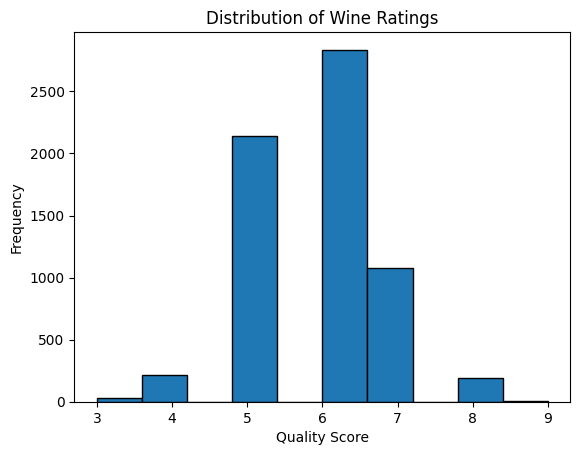

In [5]:
# 3 - Plot the wine ratings
import matplotlib.pyplot as plt

df['quality'].plot(kind='hist', bins=10, edgecolor='black')
plt.title('Distribution of Wine Ratings')
plt.xlabel('Quality Score')
plt.ylabel('Frequency')
plt.show()

## 3 - First, define $Y$ (output) as the *quality* values and $X$ as the remaining columns. Second, split the data set into train and test sets (split ratio of 50%) using a function from [scikit-learn](https://scikit-learn.org/stable/)'s *Model selection*. What can you say about the data distribution of both sets (*display them in an histogram*). Third, use parameter *stratify* to obtain the same distribution of the ratings, especially for the one with the fewest occurrences (extreme values). Once done display the new histogram to show the result.

In [6]:
from sklearn.model_selection import train_test_split
# 1 - Define X and Y
X = df.drop('quality', axis=1)
y = df['quality']
# 2 - Split data set into training and test sets using a ratio of 50%
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42)
X_train.shape, X_test.shape

((3248, 12), (3249, 12))

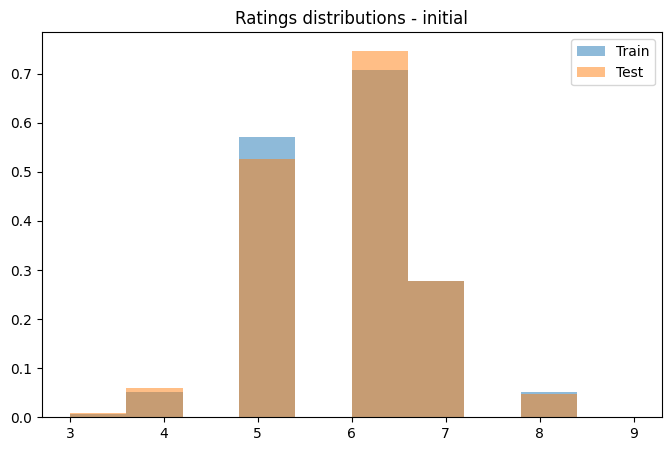

In [7]:
# 3 - Display the both data samples distributions (train and test)
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(y_train, alpha=0.5, label='Train', density=True)
ax.hist(y_test, alpha=0.5, label='Test', density=True)
ax.set_title("Ratings distributions - initial")
ax.legend();

(3248, 12) (3249, 12)


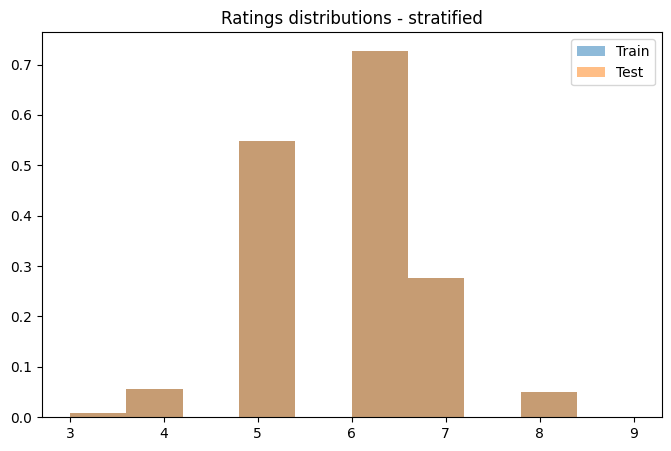

In [8]:
# 4 - Stratify the way the samples are distributed into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)
print(X_train.shape, X_test.shape)

fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(y_train, alpha=0.5, label='Train', density=True)
ax.hist(y_test, alpha=0.5, label='Test', density=True)
ax.set_title("Ratings distributions - stratified")
ax.legend();

## 4 - First, what are the types (integer, float, and so on) of values of the different variables / features of an input sample X? Second, what can you notice? Third, update the problematic variable / feature such that it becomes numeric and then split again the data set into train and test sets, but such that their respective ratio is 70% and 30%.

In [9]:
# 1 - Show the types
df.dtypes

,0
fixed_acidity,float64
volatile_acidity,float64
citric_acid,float64
residual_sugar,float64
chlorides,float64
free_sulfur_dioxide,float64
total_sulfur_dioxide,float64
density,float64
pH,float64
sulphates,float64


In [10]:
# 2 - Show the possible values of the problematic variable / feature
df['color'].value_counts()

,count
color,
white,4898
red,1599


In [11]:
# 3 - Update variable to become a numerical value
df['color'] = df['color'].map({'red': 0, 'white': 1})

# 4 - Split again data set into train and test sets (ratio 70/30)
X = df.drop('quality', axis=1)
y = df['quality']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
df.dtypes

,0
fixed_acidity,float64
volatile_acidity,float64
citric_acid,float64
residual_sugar,float64
chlorides,float64
free_sulfur_dioxide,float64
total_sulfur_dioxide,float64
density,float64
pH,float64
sulphates,float64


## 5 - First, train a classifier using logistic regression from *Linear model* in scikit-learn. Second, display the prediction obtained for each of the five first samples of the test set. Third, use the function classification_report of scikit-learn to evaluate the classifier's performance. What is support value? How are computed precision, recall and f1-score? What are macro and weighted averaging? What can you conclude from the values?

In [12]:
# 1a - Try to train logistic regression
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [13]:
# 1b - Train logistic regression again using StandardScaler as preprocessing
from sklearn import preprocessing
scaler = preprocessing.StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [14]:
# 2 - Predict value for the five first test samples
# We must scale the test data using the scaler we fitted on the train data!
X_test_scaled = scaler.transform(X_test)

Y_pred = lr.predict(X_test_scaled[:5])
print(Y_pred)

[6 6 5 6 6]


In [15]:
# 3 - Show classification performance using function classification_report of metrics
from sklearn.metrics import classification_report

y_pred = lr.predict(X_test_scaled)
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         9
           4       0.50      0.02      0.03        65
           5       0.57      0.54      0.55       642
           6       0.51      0.70      0.59       851
           7       0.53      0.26      0.35       324
           8       0.00      0.00      0.00        58
           9       0.00      0.00      0.00         1

    accuracy                           0.53      1950
   macro avg       0.30      0.22      0.22      1950
weighted avg       0.51      0.53      0.50      1950



**Support value:** The actual number of occurrences of each specific class in the test dataset.

**Precision:** The ratio of correctly predicted positive observations to the total predicted positives (TP / (TP + FP)).

**Recall:** The ratio of correctly predicted positive observations to all actual observations in that class (TP / (TP + FN)).

**F1-score:** The weighted harmonic mean of Precision and Recall.

**Macro averaging:** Calculates the metric independently for each class and then takes the unweighted mean. It treats all classes equally, regardless of their support size.

**Weighted averaging:** Calculates the metric for each class, but averages them by weighting the score by the support (accounting for class imbalance).

**Conclusion from the values:** The model achieves an overall accuracy of 55%, but this is misleading. It performs adequately only for the majority classes (quality 5 and 6) due to high support. However, it completely fails to classify minority classes (3, 4, 8, and 9), resulting in precision and recall scores of 0.00 for those categories. This indicates that the dataset is highly imbalanced, and standard Logistic Regression struggles to generalize the minority ratings, defaulting instead to predicting the most common classes.